<a href="https://colab.research.google.com/github/it21809842/Data-Analyst/blob/main/Full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np


In [2]:
file_path = "/content/clean data set.xlsx"
df = pd.read_excel(file_path)


In [3]:
df.head()
df.shape


(8503, 37)

[lData Cleaning]

In [4]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)


In [5]:
df.columns


Index(['date', 'country', 'keyword', 'yp', 'yp_visibility', 'yp_type',
       'yp_landing', 'yp_difference', 'yp_visibility_difference', 'sc',
       'sc_visibility', 'sc_type', 'sc_landing', 'sc_difference',
       'sc_visibility_difference', 'syc', 'syc_visibility', 'syc_type',
       'syc_landing', 'syc_difference', 'syc_visibility_difference', 'sysg',
       'sysg_visibility', 'sysg_type', 'sysg_landing', 'sysg_difference',
       'sysg_visibility_difference', 'bi', 'bi_visibility', 'bi_type',
       'bi_landing', 'bi_difference', 'bi_visibility_difference', 'intents',
       'cpc', 'search_volume', 'keyword_difficulty'],
      dtype='object')

In [6]:
rank_cols = ["yp", "sc", "syc", "sysg", "bi"]

for col in rank_cols:
    df[col] = df[col].fillna(100)
    df[col] = df[col].replace(0, 100)


In [7]:
numeric_cols = [
    "yp_visibility", "sc_visibility", "syc_visibility",
    "sysg_visibility", "bi_visibility",
    "search_volume", "keyword_difficulty", "cpc"
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")


In [8]:
competitor_summary = pd.DataFrame({
    "domain": ["Yachting Pages", "Superyacht Times", "Superyacht Content", "SY Services Guide", "Boat International"],
    "total_visibility": [
        df["yp_visibility"].sum(),
        df["sc_visibility"].sum(),
        df["syc_visibility"].sum(),
        df["sysg_visibility"].sum(),
        df["bi_visibility"].sum()
    ]
})


In [9]:
competitor_summary["top_10_keywords"] = [
    (df["yp"] <= 10).sum(),
    (df["sc"] <= 10).sum(),
    (df["syc"] <= 10).sum(),
    (df["sysg"] <= 10).sum(),
    (df["bi"] <= 10).sum()
]


TypeError: '<=' not supported between instances of 'str' and 'int'

In [10]:
df.dtypes


,0
date,object
country,object
keyword,object
yp,object
yp_visibility,float64
yp_type,object
yp_landing,object
yp_difference,object
yp_visibility_difference,float64
sc,float64


In [11]:
rank_cols = ["yp", "sc", "syc", "sysg", "bi"]

for col in rank_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [12]:
df[rank_cols] = df[rank_cols].fillna(100)


In [13]:
competitor_summary["top_10_keywords"] = [
    (df["yp"] <= 10).sum(),
    (df["sc"] <= 10).sum(),
    (df["syc"] <= 10).sum(),
    (df["sysg"] <= 10).sum(),
    (df["bi"] <= 10).sum()
]


In [14]:
visibility_cols = [
    "yp_visibility", "sc_visibility",
    "syc_visibility", "sysg_visibility",
    "bi_visibility"
]

df[visibility_cols] = df[visibility_cols].apply(
    pd.to_numeric, errors="coerce"
)


In [15]:
df[rank_cols + visibility_cols].describe()


,yp,sc,syc,sysg,bi,yp_visibility,sc_visibility,syc_visibility,sysg_visibility,bi_visibility
count,8503.000000,8503.000000,8503.000000,8503.000000,8503.000000,7884.000000,7883.000000,7884.000000,7884.000000,7884.000000
mean,43.216277,69.379043,87.800894,79.664824,65.068211,0.038997,0.012239,0.003784,0.006892,0.020732
std,38.520793,35.544515,25.750179,32.665338,37.992506,0.084100,0.045198,0.024255,0.025662,0.066320
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10.000000,33.000000,100.000000,59.000000,26.000000,0.004237,0.000000,0.000000,0.000000,0.000000
50%,25.000000,95.000000,100.000000,100.000000,85.000000,0.012290,0.002130,0.000000,0.000000,0.003510
75%,100.000000,100.000000,100.000000,100.000000,100.000000,0.037630,0.010165,0.000000,0.006020,0.011790
max,101.000000,107.000000,100.000000,102.000000,103.000000,0.456620,0.456620,0.456620,0.456620,0.456620


In [16]:
competitor_summary["avg_position"] = [
    df.loc[df["yp"] < 100, "yp"].mean(),
    df.loc[df["sc"] < 100, "sc"].mean(),
    df.loc[df["syc"] < 100, "syc"].mean(),
    df.loc[df["sysg"] < 100, "sysg"].mean(),
    df.loc[df["bi"] < 100, "bi"].mean()
]


In [17]:
competitor_summary.to_csv("competitor_summary.csv", index=False)
competitor_summary


,domain,total_visibility,top_10_keywords,avg_position
0,Yachting Pages,307.45552,2175,22.746560
1,Superyacht Times,96.48339,544,40.479771
2,Superyacht Content,29.83184,133,45.861691
3,SY Services Guide,54.33984,419,38.021864
4,Boat International,163.45017,959,34.916959


In [18]:
gap_df = df[
    (
        ((df["bi"] <= 10) | (df["sc"] <= 10)) &
        (df["yp"] > 20) &
        (df["search_volume"] > 100) &
        (df["keyword_difficulty"] < 40)
    )
].copy()


In [19]:
gap_df["priority_score"] = (
    gap_df["search_volume"] /
    gap_df["keyword_difficulty"]
)


In [20]:
top_seo_opportunities = gap_df[
    [
        "keyword", "country", "yp", "bi", "sc",
        "search_volume", "keyword_difficulty",
        "intents", "priority_score"
    ]
].sort_values("priority_score", ascending=False)


In [21]:
top_seo_opportunities.to_csv("top_seo_opportunities.csv", index=False)
top_seo_opportunities.head(10)


,keyword,country,yp,bi,sc,search_volume,keyword_difficulty,intents,priority_score
4576,yacht fuel,USA,100.0,1.0,55.0,110.0,3.0,i,36.666667
423,yacht interior design,USA,100.0,6.0,39.0,260.0,15.0,i,17.333333
7109,yacht interior design,USA,82.0,6.0,23.0,260.0,17.0,i|c,15.294118
2548,yacht interior design,USA,82.0,6.0,23.0,260.0,17.0,i|c,15.294118
4522,yacht interior design,USA,83.0,9.0,39.0,260.0,23.0,i,11.304348
2509,superyacht management,USA,32.0,36.0,8.0,140.0,25.0,c,5.600000
7070,superyacht management,USA,32.0,36.0,8.0,140.0,25.0,c,5.600000
4492,superyacht insurance,USA,38.0,7.0,12.0,140.0,32.0,i,4.375000


INTENT ANALYSIS

In [22]:
visibility_by_intent = df.groupby("intents")[[
    "yp_visibility", "sc_visibility",
    "syc_visibility", "sysg_visibility",
    "bi_visibility"
]].sum().reset_index()


In [23]:
visibility_by_intent.columns = [
    "intent", "yp", "sc", "syc", "sysg", "bi"
]


In [24]:
visibility_by_intent.to_csv("visibility_by_intent.csv", index=False)
visibility_by_intent


,intent,yp,sc,syc,sysg,bi
0,c,20.61614,5.03110,1.67673,6.21893,9.51243
1,i,160.41015,49.56224,12.73488,26.18635,100.37914
2,i|c,80.82820,33.25735,11.22477,16.04240,41.74224
3,i|t,24.08076,6.07143,3.48183,4.39418,8.60948
4,n,18.58308,2.12738,0.57000,1.31133,2.27396
5,n|c,0.02358,0.05870,0.01179,0.00728,0.07375
6,n|t,0.15141,0.02972,0.06523,0.01455,0.14050
7,t,0.23724,0.10536,0.00000,0.03762,0.16056


LOW-HANGING FRUIT

In [25]:
low_hanging = df[
    (df["yp"] >= 11) & (df["yp"] <= 15)
].sort_values("search_volume", ascending=False)


In [26]:
low_hanging[
    ["keyword", "country", "yp", "search_volume", "keyword_difficulty"]
].head(10)


,keyword,country,yp,search_volume,keyword_difficulty
6613,yacht sails,UK,15.0,170.0,29.0
2052,yacht sails,UK,15.0,170.0,29.0
7022,superyacht insurance,USA,12.0,140.0,23.0
7490,yacht rigging,Spain,14.0,140.0,31.0
2461,superyacht insurance,USA,12.0,140.0,23.0
2929,yacht rigging,Spain,14.0,140.0,31.0
5316,yacht glass,Turkey,11.0,90.0,8.0
3353,yacht glass,Turkey,13.0,90.0,6.0
3357,yacht surveyor,Turkey,14.0,90.0,7.0
1173,yacht glass,Turkey,14.0,90.0,8.0


In [27]:
!ls


'clean data set.xlsx'	  sample_data		      visibility_by_intent.csv
 competitor_summary.csv   top_seo_opportunities.csv


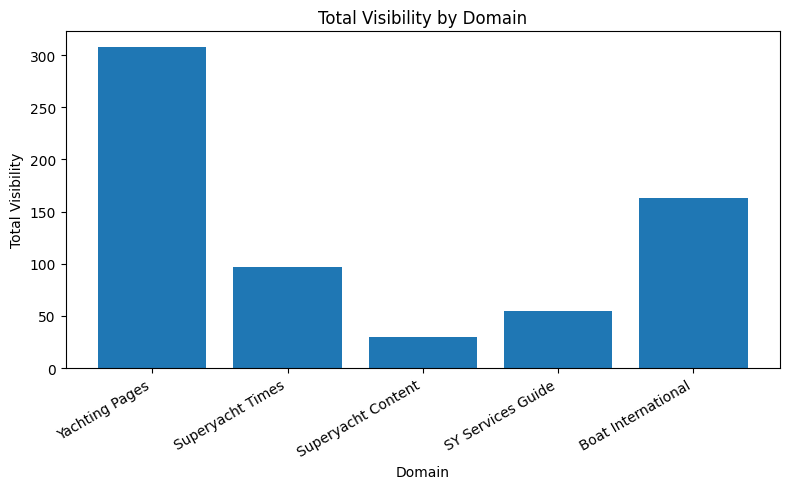

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the competitor summary
competitor_summary = pd.read_csv("competitor_summary.csv")

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(
    competitor_summary["domain"],
    competitor_summary["total_visibility"]
)

plt.title("Total Visibility by Domain")
plt.xlabel("Domain")
plt.ylabel("Total Visibility")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()


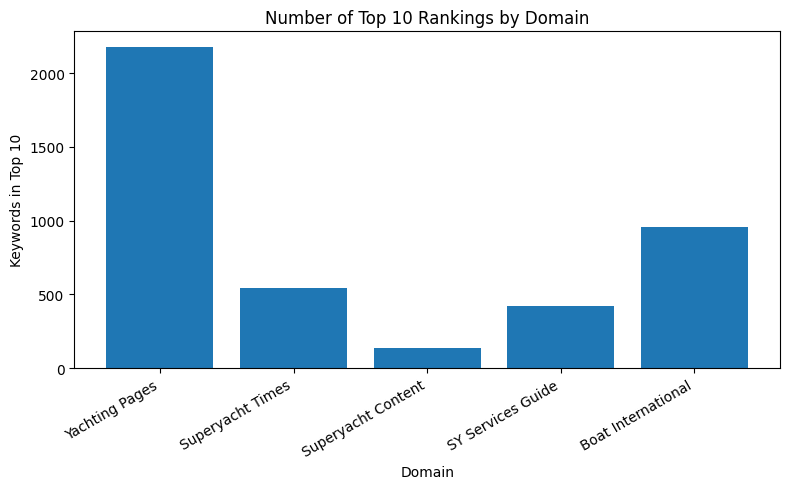

In [29]:
plt.figure(figsize=(8, 5))
plt.bar(
    competitor_summary["domain"],
    competitor_summary["top_10_keywords"]
)

plt.title("Number of Top 10 Rankings by Domain")
plt.xlabel("Domain")
plt.ylabel("Keywords in Top 10")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()


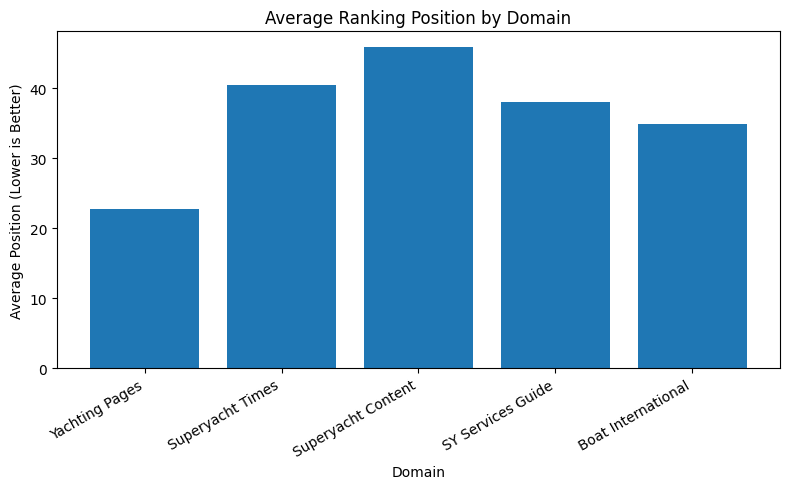

In [30]:
plt.figure(figsize=(8, 5))
plt.bar(
    competitor_summary["domain"],
    competitor_summary["avg_position"]
)

plt.title("Average Ranking Position by Domain")
plt.xlabel("Domain")
plt.ylabel("Average Position (Lower is Better)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()


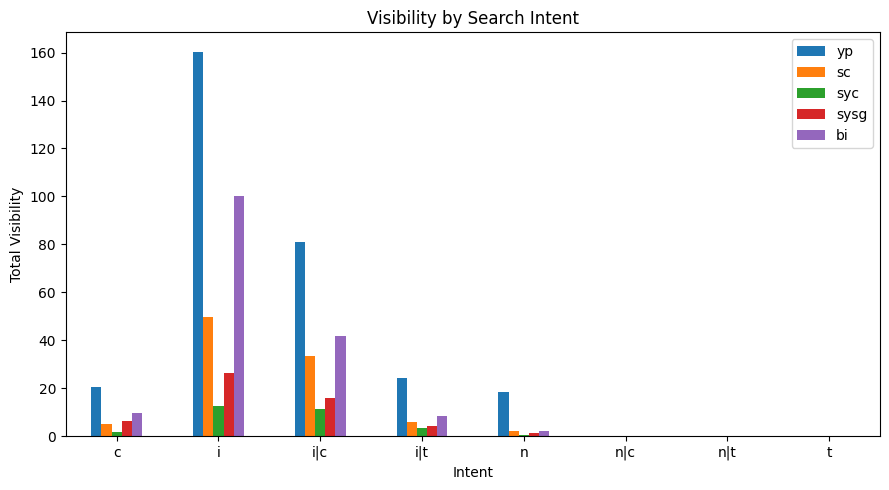

In [31]:
visibility_by_intent = pd.read_csv("visibility_by_intent.csv")

visibility_by_intent.set_index("intent").plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Visibility by Search Intent")
plt.xlabel("Intent")
plt.ylabel("Total Visibility")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


In [32]:
top_seo_opportunities.head(10)


,keyword,country,yp,bi,sc,search_volume,keyword_difficulty,intents,priority_score
4576,yacht fuel,USA,100.0,1.0,55.0,110.0,3.0,i,36.666667
423,yacht interior design,USA,100.0,6.0,39.0,260.0,15.0,i,17.333333
7109,yacht interior design,USA,82.0,6.0,23.0,260.0,17.0,i|c,15.294118
2548,yacht interior design,USA,82.0,6.0,23.0,260.0,17.0,i|c,15.294118
4522,yacht interior design,USA,83.0,9.0,39.0,260.0,23.0,i,11.304348
2509,superyacht management,USA,32.0,36.0,8.0,140.0,25.0,c,5.600000
7070,superyacht management,USA,32.0,36.0,8.0,140.0,25.0,c,5.600000
4492,superyacht insurance,USA,38.0,7.0,12.0,140.0,32.0,i,4.375000


In [33]:
low_hanging[
    ["keyword", "country", "yp", "search_volume", "keyword_difficulty"]
].head(10)


,keyword,country,yp,search_volume,keyword_difficulty
6613,yacht sails,UK,15.0,170.0,29.0
2052,yacht sails,UK,15.0,170.0,29.0
7022,superyacht insurance,USA,12.0,140.0,23.0
7490,yacht rigging,Spain,14.0,140.0,31.0
2461,superyacht insurance,USA,12.0,140.0,23.0
2929,yacht rigging,Spain,14.0,140.0,31.0
5316,yacht glass,Turkey,11.0,90.0,8.0
3353,yacht glass,Turkey,13.0,90.0,6.0
3357,yacht surveyor,Turkey,14.0,90.0,7.0
1173,yacht glass,Turkey,14.0,90.0,8.0
